## Settings

In [1]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [2]:
## libraries
import sys
import pandas as pd
from pathlib import Path
from IPython.display import Markdown, display

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators
from src.evaluators.metrics import spec_marginal_delta
from src.evaluators.decomposing import (
    train_decomposed_separation,
    train_decomposed_attribution,
    compile_decomposed_separation,
    compile_decomposed_attribution,
    compile_decomposed_consensus,
    stat_decomposed_summary,
    stat_decomposed_attribution,
    stat_decomposed_test,
    )
from src.evaluators.tables import main_table
from src.visualizers.visualizing import plot_consensus

## constants
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z,
    TARGET,
    FRONTIER_METRICS,
    CONSENSUS_METRICS,
    )

## Initialization

In [3]:
## reproducibility
N_DECIMALS = 2
RANDOM_STATE = 42
N_REPEATS = 30

## load data and models
data = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [4]:
## train decomposed residual attribution
cached_decomposed_attribution = globals().get("results_dict_decomposed_attribution")
if (
    not isinstance(cached_decomposed_attribution, dict)
    or cached_decomposed_attribution.get("n_repeats") != N_REPEATS
    or cached_decomposed_attribution.get("random_state") != RANDOM_STATE
):
    results_dict_decomposed_attribution = train_decomposed_attribution(
        data = data,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

Residual attribution evaluation:   0%|                 | 0/9 [00:00<?, ?model/s]

Residual attribution evaluation:  11%|█        | 1/9 [00:04<00:39,  4.91s/model]

Residual attribution evaluation:  33%|███      | 3/9 [00:06<00:11,  1.84s/model]

Residual attribution evaluation:  44%|████     | 4/9 [00:19<00:28,  5.60s/model]

Residual attribution evaluation:  56%|█████    | 5/9 [00:21<00:18,  4.53s/model]

Residual attribution evaluation:  67%|██████   | 6/9 [00:23<00:11,  3.82s/model]

Residual attribution evaluation:  78%|███████  | 7/9 [02:04<01:08, 34.31s/model]

Residual attribution evaluation:  89%|████████ | 8/9 [02:08<00:24, 24.80s/model]

Residual attribution evaluation: 100%|█████████| 9/9 [02:11<00:00, 18.10s/model]

Residual attribution evaluation: 100%|█████████| 9/9 [02:11<00:00, 14.58s/model]

In [5]:
## train decomposed separation
cached_decomposed_separation = globals().get("results_dict_decomposed_separation")
if (
    not isinstance(cached_decomposed_separation, dict)
    or cached_decomposed_separation.get("n_repeats") != N_REPEATS
    or cached_decomposed_separation.get("random_state") != RANDOM_STATE
):
    results_dict_decomposed_separation = train_decomposed_separation(
        data = data,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

Separation evaluation:   0%|                           | 0/9 [00:00<?, ?model/s]

Separation evaluation:  11%|██                 | 1/9 [00:10<01:25, 10.69s/model]

Separation evaluation:  22%|████▏              | 2/9 [00:14<00:46,  6.61s/model]

Separation evaluation:  33%|██████▎            | 3/9 [00:17<00:29,  4.94s/model]

Separation evaluation:  44%|████████▍          | 4/9 [01:03<01:46, 21.23s/model]

...

Separation evaluation:  67%|████████████▋      | 6/9 [01:56<01:13, 24.36s/model]

Separation evaluation:  78%|██████████████▊    | 7/9 [06:03<03:13, 96.94s/model]

Separation evaluation:  89%|████████████████▉  | 8/9 [06:16<01:10, 70.29s/model]

Separation evaluation: 100%|███████████████████| 9/9 [06:30<00:00, 52.82s/model]

Separation evaluation: 100%|███████████████████| 9/9 [06:30<00:00, 43.44s/model]

## Post-Processing

In [6]:
## compile decomposed residual attribution results
results_decomposed_attribution, predictions_decomposed_attribution = compile_decomposed_attribution(
    results = results_dict_decomposed_attribution
)

## compile decomposed separation results
results_decomposed_separation, predictions_decomposed_separation = compile_decomposed_separation(
    results = results_dict_decomposed_separation
)

## compile decomposed pairwise consensus results
results_decomposed_consensus = compile_decomposed_consensus(
    predictions = predictions_decomposed_separation
)

## persist decomposed separation frame for the universality consensus-vs-validity scatter
import pickle
_validity_cache_path = root / "outputs" / "cache" / "validity_frames.pkl"
_validity_cache_path.parent.mkdir(parents = True, exist_ok = True)
_validity_payload = (
    pickle.loads(_validity_cache_path.read_bytes())
    if _validity_cache_path.exists() else dict()
)
_validity_payload["results_decomposed_separation"] = results_decomposed_separation
_validity_cache_path.write_bytes(pickle.dumps(_validity_payload))
print(f"Cached {len(results_decomposed_separation)} decomposed separation rows -> {_validity_cache_path}")

Cached 270 decomposed separation rows -> /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/cache/validity_frames.pkl


## Residual Attribution Test
The residual attribution test probes whether, after estimating the capacity stage $C(X)$, the remaining slack is better predicted from dynamics than from topology. Under the additive decomposition $y^* = C(X) + R(Z)$, the residual slack $s = y^* - \hat{C}(X)$ should be more predictable from $Z$ than from $X$. Each contrast is evaluated with a paired one-sided Wilcoxon signed-rank statistic on domain-level mean absolute error (MAE).

- **$H_0$**: Topology predicts residual slack at least as well as dynamics ($\Delta \mathrm{MAE} \le 0$).
- **$H_1$**: Dynamics predict residual slack better than topology ($\Delta \mathrm{MAE} > 0$).

Rejecting $H_0$ establishes that residual slack is more predictably attributable to dynamics than to unrecovered topological information after conditioning on $C(X)$.

### Decomposition Protocol
Separate learners are fit for $X \to s$ and $Z \to s$ within repeated-seed LOGO-CV (domain) splits. Predictions are averaged across seeds, then aggregated to one MAE value per (model $\times$ domain) for each residual-input source.

### Empirical Test Specification
Paired differences are formed as $\Delta \mathrm{MAE} = \mathrm{MAE}_{X \to s} - \mathrm{MAE}_{Z \to s}$ on matched (model $\times$ domain) units. The table reports the paired median shift, rank-biserial effect size, and Holm-adjusted one-sided p-value summarizing whether the dynamics-based residual model consistently outperforms the topology-based residual model.

In [7]:
## one-sided wilcoxon test for residual attribution
results_attribution = stat_decomposed_attribution(
    predictions = predictions_decomposed_attribution,
    decimals = N_DECIMALS,
)

display(results_attribution)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ MAE ≤ 0
H₁: Δ MAE > 0
Median Δ MAE: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor Z -> slack
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ MAE > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,,Median Δ MAE,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,Diff.
Property,Comparison,,,,,,
Residual Attribution,Topology vs Dynamics,0.61,0.53,0.00,0.00,***,Yes


_Residual slack is predicted more accurately from dynamics than from topology, with a positive median MAE shift and a significant one-sided Wilcoxon result. This means the additive decomposition is not splitting predictors into arbitrary blocks. After the capacity component $C(X)$ is removed, the remaining explainable variation aligns with dynamic information rather than leftover topological signal. The result supports a clear division: topology carries baseline capacity, and dynamics carry the residual structure that remains after capacity is accounted for._

## Parsimonious Sufficiency Tests
The parsimonious sufficiency tests probe whether the additive decomposition $C(X) + R(Z)$ is non-inferior to all considered test specifications, both richer and simpler. Two performance dimensions are evaluated independently for each comparison: the efficiency index (EI) measures frontier placement accuracy, and the consensus index (CI) measures rank-order agreement.

### Unified Non-Inferiority Claim
For every test specification -- interaction-augmented residual, joint, capacity-only, and dynamics-only -- the claim is that the test specification does not meaningfully outperform the original additive reference. Each test specification is compared against the original additive reference with a paired one-sided Wilcoxon signed-rank statistic under an empirically derived margin $\delta$.

- **$H_0$**: The test specification exceeds the original additive reference by at least $\delta$ ($\Delta \ge \delta$).
- **$H_1$**: The test specification does not exceed the original additive reference by $\delta$ ($\Delta < \delta$).

Rejecting $H_0$ establishes that the test specification fails to produce a practically meaningful improvement over the original additive form. Simpler specifications, which are expected to perform no better than the additive reference, satisfy the same test trivially when their paired gaps lie at or below the original additive level.

### Decomposition Protocol
All specifications are fit under repeated-seed LOGO-CV (domain): original additive $C(X) + R(Z)$, interaction-augmented residual, joint, capacity-only, and dynamics-only. Predictions are averaged across seeds before scoring per (model $\times$ domain).

### Reporting Convention
The descriptive summary reports median `[IQR]` EI across matched (model $\times$ domain) units, with `VR`, `MV`, and `MS` included as auxiliary frontier diagnostics. This table provides the empirical scale for the tests below.

### Empirical Test Specification
The margin $\delta$ is set from the interquartile range of original additive-reference values, anchoring the test to natural variability under the reference specification. Paired gaps are formed as $\Delta = \text{score}_{\text{test}} - \text{score}_{\text{original}}$, and each table reports the median paired gap, rank-biserial effect size, Holm-adjusted one-sided p-value, and decision for each test specification.

In [8]:
## empirical delta for EI tests
delta_ei = spec_marginal_delta(
    results = results_decomposed_separation,
    feat_value = ["ei"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 1.0,  ## full iqr range
    decimals = N_DECIMALS
)

## empirical delta for CI tests
delta_ci = spec_marginal_delta(
    results = results_decomposed_separation,
    feat_value = ["ci"],
    label_ref = "specification",
    value_ref = "additive",
    method = "iqr",
    scale = 0.30,  ## 30% of iqr range
    decimals = N_DECIMALS
)


In [9]:
## non-inferiority test: richer specifications on EI
results_complex_ei = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ei,
    metric = "ei",
    specs = ("interaction", "joint"),
    direction = "noninferiority",
    decimals = N_DECIMALS)

display(results_complex_ei)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.08, metric = EI
H₀: Δ EI ≥ δ
H₁: Δ EI < δ
NI.: Yes if Holm-adj. p < 0.05 and Median Δ EI < δ
Median Δ EI: Median of paired differences (Test - Original)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ EI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Interaction,0.00,0.91,0.00,0.00,***,Yes
Joint,-0.01,0.72,0.00,0.00,***,Yes


In [10]:
## non-inferiority test: complex specifications on CI
results_complex_ci = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ci,
    metric = "ci",
    specs = ("interaction", "joint"),
    direction = "noninferiority",
    decimals = N_DECIMALS
)
display(results_complex_ci)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.08, metric = CI
H₀: Δ CI ≥ δ
H₁: Δ CI < δ
NI.: Yes if Holm-adj. p < 0.05 and Median Δ CI < δ
Median Δ CI: Median of paired differences (Test - Original)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ CI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Interaction,-0.03,0.79,0.00,0.00,***,Yes
Joint,-0.22,0.84,0.00,0.00,***,Yes


In [11]:
## non-inferiority test: simple specifications on EI
results_simple_ei = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ei,
    metric = "ei",
    specs = ("capacity_only", "dynamics_only"),
    direction = "noninferiority",
    decimals = N_DECIMALS
)

display(results_simple_ei)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.08, metric = EI
H₀: Δ EI ≥ δ
H₁: Δ EI < δ
NI.: Yes if Holm-adj. p < 0.05 and Median Δ EI < δ
Median Δ EI: Median of paired differences (Test - Original)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ EI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Capacity Only,-0.01,0.97,0.00,0.00,***,Yes
Dynamics Only,-0.00,0.71,0.00,0.00,***,Yes


In [12]:
## non-inferiority test: simple specifications on CI
results_simple_ci = stat_decomposed_test(
    results = results_decomposed_separation,
    delta = delta_ci,
    metric = "ci",
    specs = ("capacity_only", "dynamics_only"),
    direction = "noninferiority",
    decimals = N_DECIMALS
)
display(results_simple_ci)

Paired Non-Inferiority Test (Wilcoxon Signed-Rank): n = 45, δ = 0.08, metric = CI
H₀: Δ CI ≥ δ
H₁: Δ CI < δ
NI.: Yes if Holm-adj. p < 0.05 and Median Δ CI < δ
Median Δ CI: Median of paired differences (Test - Original)
Rank-biserial r: Paired effect size, positive values favor the tested direction
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


,Median Δ CI,Rank-biserial r,One-sided p,Holm-adj. p,Sig.,NI.
Specification,,,,,,
Capacity Only,-0.39,0.91,0.00,0.00,***,Yes
Dynamics Only,-0.19,0.79,0.00,0.00,***,Yes


In [13]:
## median decomposition metrics by specification
DECOMPOSITION_REPORT_SPECS = (
    "additive",
    "capacity_only",
    "dynamics_only",
    "interaction",
    "joint",
)
results_decomposed_report = results_decomposed_separation.loc[
    results_decomposed_separation["specification"].isin(DECOMPOSITION_REPORT_SPECS)
].copy()

decomposed_summary = stat_decomposed_summary(
    results = results_decomposed_report,
    metric = "ei",
    spec_order = DECOMPOSITION_REPORT_SPECS,
    decimals = N_DECIMALS,
)

display(decomposed_summary)


EI [IQR]    VR    MV    MS
Specification Method                                            
Original      Original       0.77 [0.73, 0.82]  0.01  0.01  4.76
Simple        Capacity Only  0.76 [0.70, 0.80]  0.00  0.00  5.46
              Dynamics Only  0.77 [0.75, 0.83]  0.00  0.00  4.58
Complex       Interaction    0.78 [0.73, 0.83]  0.00  0.00  5.31
              Joint          0.76 [0.74, 0.82]  0.00  0.00  4.89

In [14]:
## median decomposition metrics by specification (CI)
results_decomposed_report = results_decomposed_separation.loc[
    results_decomposed_separation["specification"].isin(DECOMPOSITION_REPORT_SPECS)
].copy()

decomposed_summary_ci = stat_decomposed_summary(
    results = results_decomposed_report,
    metric = "ci",
    spec_order = DECOMPOSITION_REPORT_SPECS,
    decimals = N_DECIMALS,
)

display(decomposed_summary_ci)


CI [IQR]  RHO   RBO   DCR
Specification Method                                           
Original      Original       0.88 [0.68, 0.96]  0.7  0.90  0.86
Simple        Capacity Only  0.46 [0.00, 0.76]  0.0  0.81  0.50
              Dynamics Only  0.62 [0.00, 0.86]  0.1  0.83  0.55
Complex       Interaction    0.78 [0.63, 0.92]  0.6  0.85  0.75
              Joint          0.65 [0.00, 0.81]  0.0  0.83  0.56

_No alternative specification — richer or simpler — improves on the additive form by a practically meaningful margin on either EI or CI. Each Holm-adjusted one-sided Wilcoxon test rejects the hypothesis that the alternative outperforms additive by at least $\delta$, with simpler specifications (capacity-only and dynamics-only) sitting at or below the additive level and richer specifications (interaction, joint) showing no consistent gain. Together, these tests support $C(X) + R(Z)$ as a sufficient specification: added complexity does not pay off, and reduced specifications do not surpass it. Topology carries baseline capacity, dynamics carry the remaining structured variation, and the additive form stands as the parsimonious reference._

## Summary

In [15]:
## manuscript summary table for decomposition validity
def _prep_spec_table(results: pd.DataFrame, category: str, decision_col: str = "NI.") -> pd.DataFrame:
    frame = results.reset_index().copy()
    frame = frame.rename(columns = {"Specification": "Method", decision_col: "Decision"})
    frame["Specification"] = category
    return frame

## ei side (domain transfer)
summary_ei = pd.concat(
    objs = [
        _prep_spec_table(results = results_complex_ei, category = "Complex"),
        _prep_spec_table(results = results_simple_ei, category = "Simple"),
    ],
    ignore_index = True,
)

## ci side (structural agreement)
summary_ci = pd.concat(
    objs = [
        _prep_spec_table(results = results_complex_ci, category = "Complex"),
        _prep_spec_table(results = results_simple_ci, category = "Simple"),
    ],
    ignore_index = True,
)

display_table = main_table(
    results_left = summary_ei,
    results_right = summary_ci,
    index_feat = ["Specification", "Method"],
    value_feat_left = ["Median Δ EI", "Rank-biserial r", "Sig.", "Decision"],
    value_feat_right = ["Median Δ CI", "Rank-biserial r", "Sig.", "Decision"],
    header_left = "Domain Transfer",
    header_right = "Structural Agreement",
    short_feat_left = ["Δ EI", "r", "Sig.", "N/I"],
    short_feat_right = ["Δ CI", "r", "Sig.", "N/I"],
    row_order = [
        ("Simple", "Capacity"),
        ("Simple", "Dynamics"),
        ("Complex", "Interaction"),
        ("Complex", "Joint")
    ],
)

display(display_table)
display(
    Markdown(
        "**Δ EI**, **Δ CI**: median paired difference Δ = Test - Original, where Test is the listed specification and Original is the additive reference; negative values favor the original additive reference. "
        "**r**: rank-biserial correlation effect size, with positive values favoring the tested one-sided claim. "
        "**Sig.**: Holm-adjusted one-sided Wilcoxon signed-rank *p* below threshold within each outcome "
        "(\*\*\* *p* < 0.001, \*\* *p* < 0.01, \* *p* < 0.05); significance supports the unified non-inferiority claim H₁: Δ < δ, that the test specification does not outperform the original additive reference by the margin. "
        "**Non-Inferior**: additive is supported as non-inferior when Holm-adjusted *p* < 0.05 and median Δ < δ. "
        "Margin δ = IQR derived from natural variability in the additive reference (EI: full IQR; CI: 30% of IQR). "
        "Each test is conducted on *n* = 45 (9 models × 5 domains)."
    )
)

Domain Transfer                  \
                                       Δ EI     r Sig.  N/I   
Specification Method                                          
Complex       Interaction              0.00  0.91  ***  Yes   
              Joint                   -0.01  0.72  ***  Yes   
Simple        Capacity Only           -0.01  0.97  ***  Yes   
              Dynamics Only           -0.00  0.71  ***  Yes   

                            Structural Agreement                  
                                            Δ CI     r Sig.  N/I  
Specification Method                                              
Complex       Interaction                  -0.03  0.79  ***  Yes  
              Joint                        -0.22  0.84  ***  Yes  
Simple        Capacity Only                -0.39  0.91  ***  Yes  
              Dynamics Only                -0.19  0.79  ***  Yes

**Δ EI**, **Δ CI**: median paired difference Δ = Test - Original, where Test is the listed specification and Original is the additive reference; negative values favor the original additive reference. **r**: rank-biserial correlation effect size, with positive values favoring the tested one-sided claim. **Sig.**: Holm-adjusted one-sided Wilcoxon signed-rank *p* below threshold within each outcome (\*\*\* *p* < 0.001, \*\* *p* < 0.01, \* *p* < 0.05); significance supports the unified non-inferiority claim H₁: Δ < δ, that the test specification does not outperform the original additive reference by the margin. **Non-Inferior**: additive is supported as non-inferior when Holm-adjusted *p* < 0.05 and median Δ < δ. Margin δ = IQR derived from natural variability in the additive reference (EI: full IQR; CI: 30% of IQR). Each test is conducted on *n* = 45 (9 models × 5 domains).

## Visualization

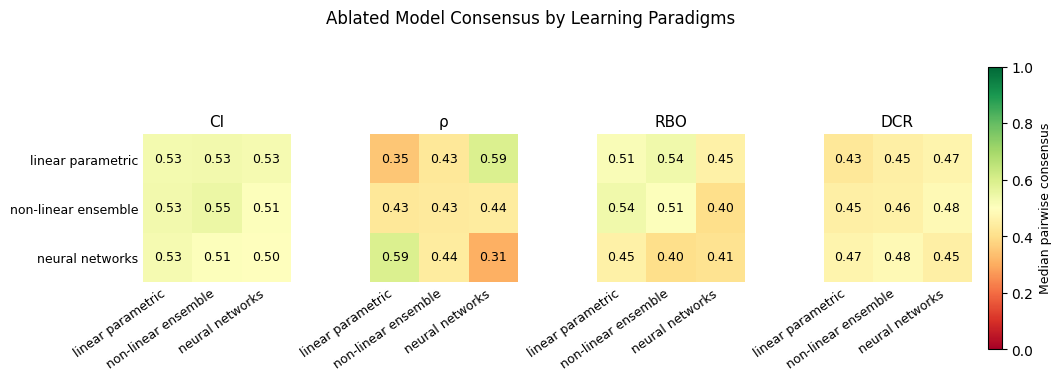

In [16]:
## paradigm-level consensus heatmaps
results_decomposed_consensus_ablate = results_decomposed_consensus.loc[
    results_decomposed_consensus["specification"] != "additive"
].copy()

fig, ax, mat = plot_consensus(
    results = results_decomposed_consensus_ablate,
    title = "Ablated Model Consensus by Learning Paradigms",
)